In [1]:
from collections import Counter

import pandas as pd
from torchvision import transforms

from transformers import logging as transformers_logging

from weather.models import *
from weather.dataset.dataloader import *
from weather.config import *
from weather.utils.train import Pipeline
from weather.utils.visualize import compare_models, plot_confusion_matrices

transformers_logging.set_verbosity_info()

import warnings

warnings.filterwarnings("ignore")

/Users/veronika_steklo/PycharmProjects/ML_NN_SSU/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
set_seed(SEED)

# Загрузка данных

In [3]:
data, loaders, all_labels, class_names = get_weather_loaders(DATA_PATH)

Ищу данные по пути: /Users/veronika_steklo/PycharmProjects/ML_NN_SSU/data/weather_dataset


In [4]:
train_data = data['train']
val_data = data['val']
test_data = data['test']

In [5]:
train_loader = loaders['train']
val_loader = loaders['val']
test_loader = loaders['test']

In [6]:
def get_stats(subset, all_labels, class_names):
    subset_labels = [all_labels[i] for i in subset.subset.indices]
    counts = Counter(subset_labels)
    return {class_names[i]: counts.get(i, 0) for i in range(len(class_names))}

In [7]:
stats = {
    'train': get_stats(train_data, all_labels, class_names),
    'val': get_stats(val_data, all_labels, class_names),
    'test': get_stats(test_data, all_labels, class_names)
}

In [8]:
df_stats = pd.DataFrame(stats).T
df_stats['Total'] = df_stats.sum(axis=1)
df_stats

,dew,fogsmog,frost,glaze,hail,lightning,rain,rainbow,rime,sandstorm,snow,Total
train,474,578,323,434,402,257,358,158,789,470,422,4665
val,119,145,81,109,100,64,89,39,197,118,106,1167
test,105,128,71,96,89,56,79,35,174,104,93,1030


## Обучение

In [9]:
num_classes = len(class_names)

### MLP

In [10]:
mlp_model = Perceptron(128 * 128 * 3, num_classes=num_classes)

In [11]:
mlp_pipeline = Pipeline(
    model=mlp_model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    class_names=class_names,
    device=DEVICE,
    epochs=30,
    patience=5,
    model_name="mlp_weather"
)

In [12]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)

Результаты на 5 эпохе:
   Train Loss: 1.8760 | Train Acc: 37.1490%
   Val Loss:   1.6557 | Val Acc:   47.2151% | Conf: 47.11%
Результаты на 10 эпохе:
   Train Loss: 1.7819 | Train Acc: 41.0718%
   Val Loss:   1.6193 | Val Acc:   48.7575% | Conf: 48.55%
Результаты на 15 эпохе:
   Train Loss: 1.7125 | Train Acc: 42.9796%
   Val Loss:   1.4821 | Val Acc:   50.0428% | Conf: 53.31%
Результаты на 20 эпохе:
   Train Loss: 1.6498 | Train Acc: 45.1447%
   Val Loss:   1.4381 | Val Acc:   52.3565% | Conf: 50.70%
Результаты на 25 эпохе:
   Train Loss: 1.6001 | Train Acc: 46.2594%
   Val Loss:   1.3944 | Val Acc:   55.6984% | Conf: 52.17%
Результаты на 30 эпохе:
   Train Loss: 1.5836 | Train Acc: 47.5027%
   Val Loss:   1.3843 | Val Acc:   55.6127% | Conf: 51.30%
Точность на тестовой выборке: 54.3689%
Средняя уверенность на тестовой выборке: 51.05%


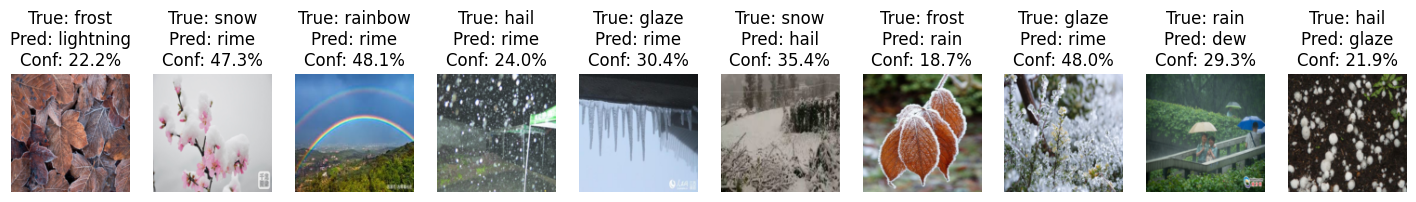

Статистика уверенности:
  Правильные предсказания: 62.02% ± 25.21%
  Неправильные предсказания: 37.99% ± 18.44%
  Общая уверенность: 51.05%


In [13]:
mlp_history = mlp_pipeline.train(criterion, optimizer)

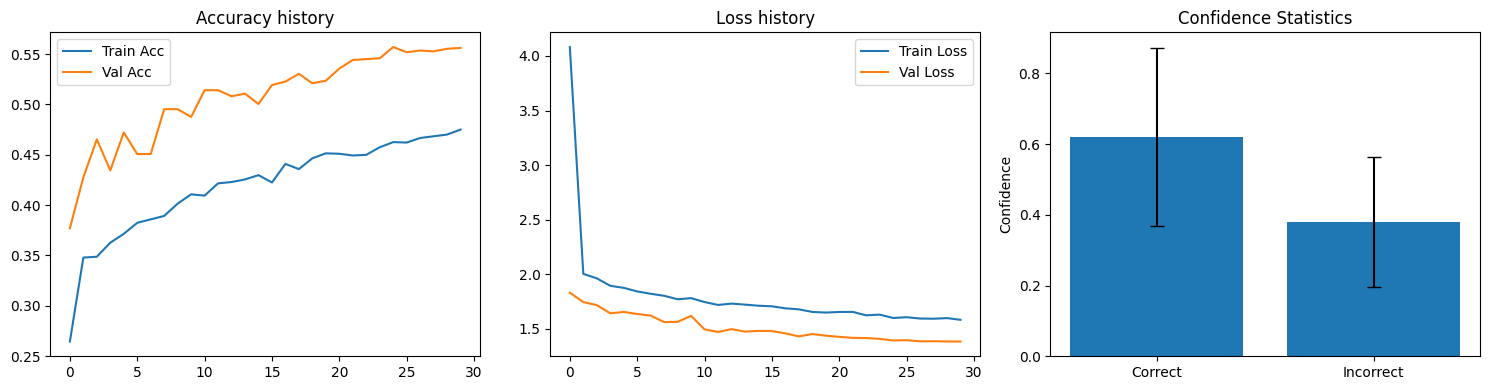

In [14]:
mlp_pipeline.plot_history()

### CNN

In [27]:
cnn_model = CNN(num_classes=num_classes)

In [28]:
cnn_pipeline = Pipeline(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    class_names=class_names,
    device=DEVICE,
    epochs=30,
    patience=5,
    model_name="cnn_weather"
)

In [29]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

Результаты на 5 эпохе:
   Train Loss: 1.2719 | Train Acc: 55.9271%
   Val Loss:   1.0535 | Val Acc:   61.8680% | Conf: 62.79%
Результаты на 10 эпохе:
   Train Loss: 1.1245 | Train Acc: 60.9646%
   Val Loss:   0.9182 | Val Acc:   66.4953% | Conf: 66.38%
Результаты на 15 эпохе:
   Train Loss: 1.0308 | Train Acc: 63.8800%
   Val Loss:   0.8452 | Val Acc:   70.7798% | Conf: 68.02%
Ранняя остановка на 17 эпохе | Best Loss: 0.8041
Точность на тестовой выборке: 72.5243%
Средняя уверенность на тестовой выборке: 69.79%


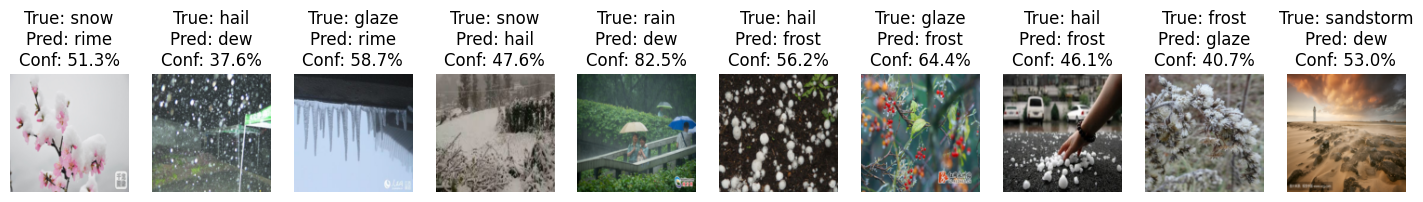

Статистика уверенности:
  Правильные предсказания: 76.58% ± 20.16%
  Неправильные предсказания: 51.89% ± 16.88%
  Общая уверенность: 69.79%


In [30]:
cnn_history = cnn_pipeline.train(criterion, optimizer)

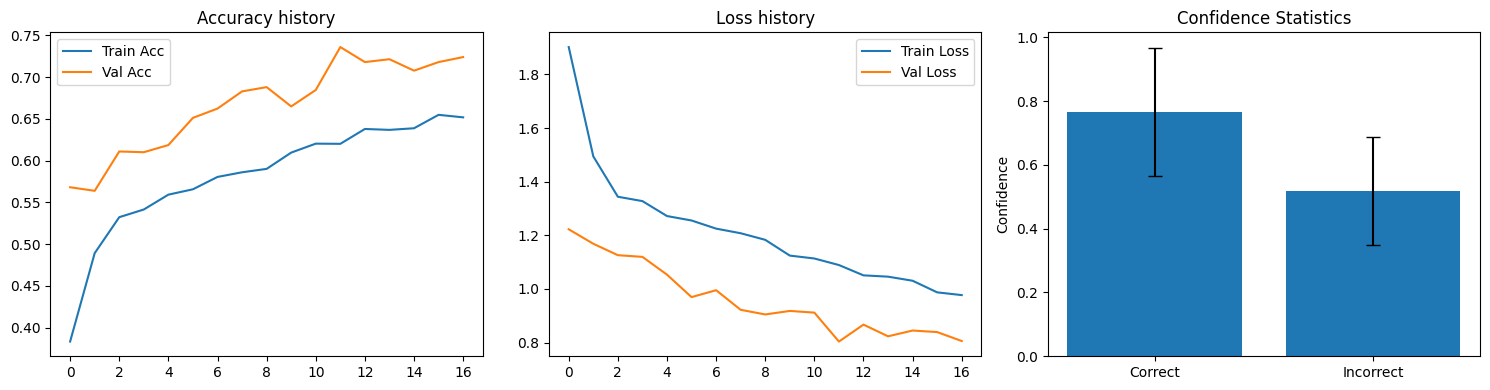

In [31]:
cnn_pipeline.plot_history()

### MobileNetV3

In [ ]:
model_mobilenet = get_mobilenet(num_classes=num_classes)

In [32]:
model_mobilenet.to(DEVICE)

MobileNetV3(
  (conv_stem): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): Hardswish()
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
        (bn1): BatchNormAct2d(
          16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): ReLU(inplace=True)
          (conv_expand): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (gate): Hardsigmoid()
        )
        (conv_pw): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): B

In [33]:
mobilenet_pipeline = Pipeline(
    model=model_mobilenet,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    class_names=class_names,
    device=DEVICE,
    epochs=15,
    model_name="mobilenet_weather"
)

In [34]:
optimizer = torch.optim.AdamW(model_mobilenet.parameters(), lr=1e-4)
criterion = torch.nn.CrossEntropyLoss()

Результаты на 5 эпохе:
   Train Loss: 0.7286 | Train Acc: 75.4555%
   Val Loss:   0.6085 | Val Acc:   78.5775% | Conf: 83.76%
Результаты на 10 эпохе:
   Train Loss: 0.5250 | Train Acc: 81.5434%
   Val Loss:   0.4826 | Val Acc:   84.0617% | Conf: 86.42%
Результаты на 15 эпохе:
   Train Loss: 0.4401 | Train Acc: 84.1158%
   Val Loss:   0.4587 | Val Acc:   85.0900% | Conf: 87.05%
Точность на тестовой выборке: 82.7184%
Средняя уверенность на тестовой выборке: 86.98%


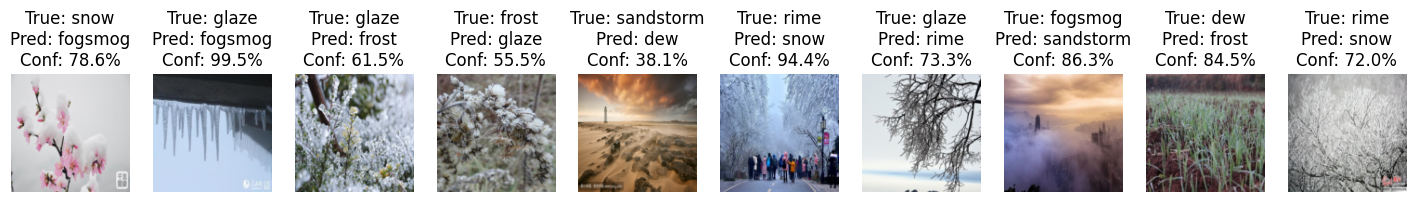

Статистика уверенности:
  Правильные предсказания: 91.35% ± 14.37%
  Неправильные предсказания: 66.06% ± 18.11%
  Общая уверенность: 86.98%


In [35]:
mobilenet_history = mobilenet_pipeline.train(criterion, optimizer)

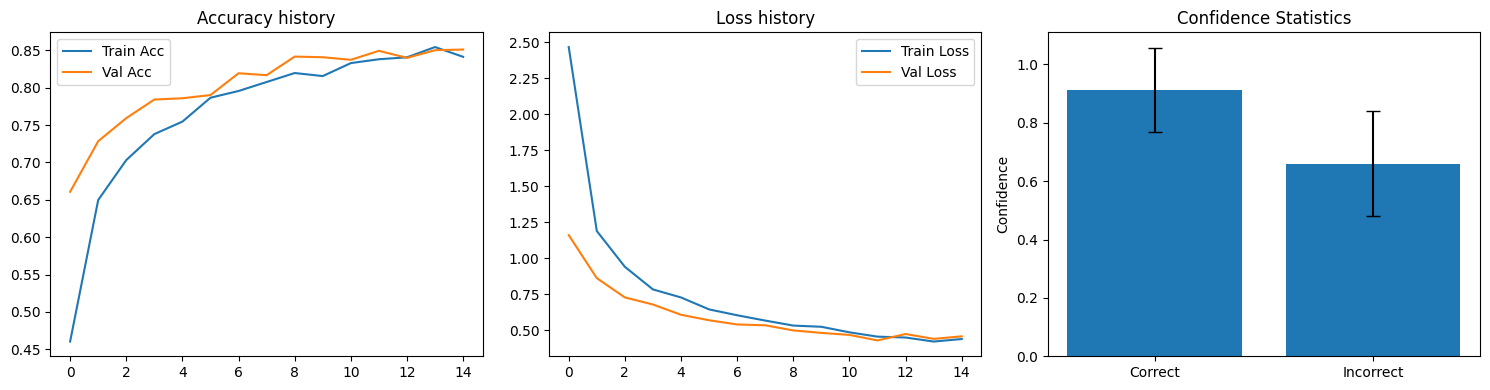

In [36]:
mobilenet_pipeline.plot_history()

### ViTImageProcessor

In [ ]:
model_name = "google/vit-base-patch16-224"

In [ ]:
vit_model, vit_info = get_vit_model(class_names=class_names, device=DEVICE)
vit_model.to(DEVICE)

In [ ]:
mu = vit_info['mu']
std = vit_info['std']
vit_size = vit_info['size']

In [40]:
vit_transforms = transforms.Compose([
    transforms.Resize((vit_size, vit_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mu, std=std)
])

In [ ]:
vit_data, vit_loaders, vit_targets, vit_classes = get_weather_loaders(DATA_PATH, image_size=224)

In [ ]:
vit_training_data = vit_data["train"]
vit_val_data = vit_data["val"]
vit_test_data = vit_data["test"]

In [ ]:
vit_train_loader = vit_loaders['train']
vit_val_loader = vit_loaders['val']
vit_test_loader = vit_loaders['test']

In [43]:
wrapped_vit = ViTWrapper(vit_model)

In [44]:
vit_pipeline = Pipeline(
    model=wrapped_vit,
    train_loader=vit_train_loader,
    val_loader=vit_val_loader,
    test_loader=vit_test_loader,
    class_names=class_names,
    device=DEVICE,
    epochs=10,
    patience=3,
    model_name="vit_weather"
)

In [45]:
optimizer = torch.optim.AdamW(vit_model.parameters(), lr=2e-5)
criterion = torch.nn.CrossEntropyLoss()

Результаты на 5 эпохе:
   Train Loss: 0.0183 | Train Acc: 99.8499%
   Val Loss:   0.1965 | Val Acc:   93.4019% | Conf: 94.91%
Ранняя остановка на 8 эпохе | Best Loss: 0.1965
Точность на тестовой выборке: 93.2039%
Средняя уверенность на тестовой выборке: 96.33%


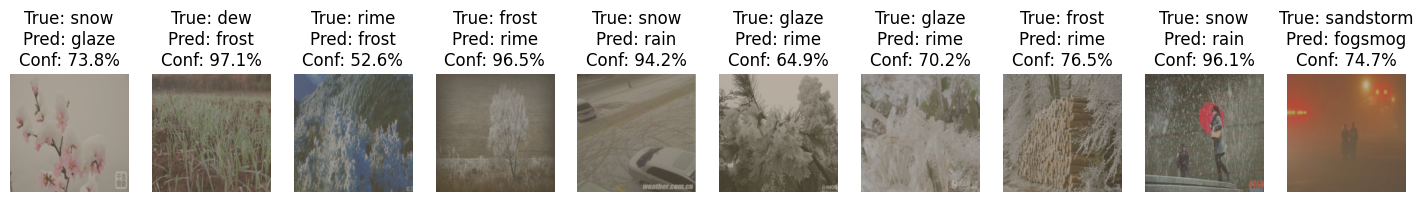

Статистика уверенности:
  Правильные предсказания: 97.54% ± 7.26%
  Неправильные предсказания: 79.77% ± 19.34%
  Общая уверенность: 96.33%


In [46]:
vit_history = vit_pipeline.train(criterion, optimizer)

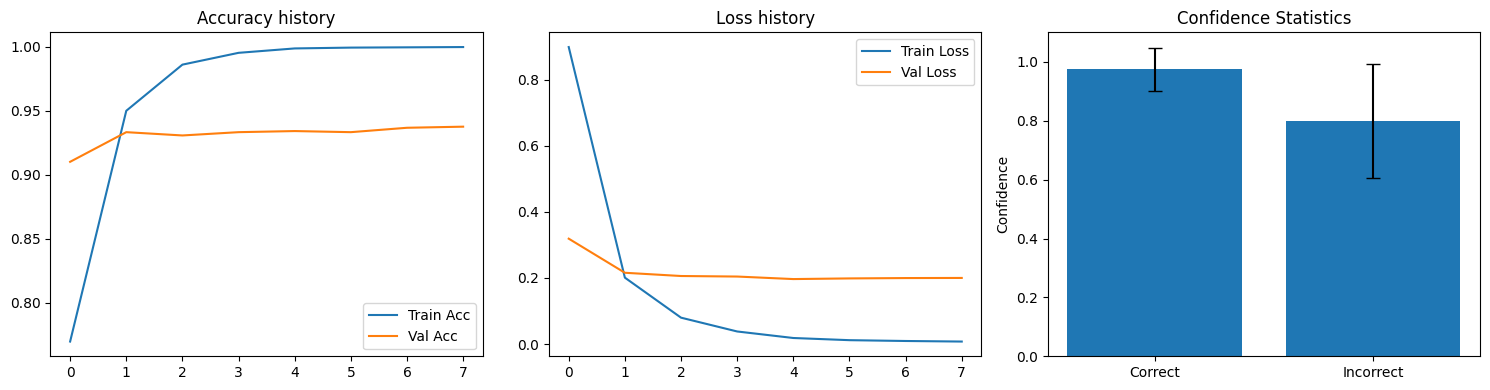

In [47]:
vit_pipeline.plot_history()

### ResNet

In [71]:
resnet_model = get_resnet50(num_classes=num_classes)
resnet_model = resnet_model.to(DEVICE)

In [72]:
optimizer = torch.optim.Adam(resnet_model.parameters(), lr=1e-4)
criterion = torch.nn.CrossEntropyLoss()

In [73]:
resnet_pipeline = Pipeline(
    model=resnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    class_names=class_names,
    device=DEVICE,
    epochs=20,
    patience=5,
    model_name="resnet50_weather"
)

Результаты на 5 эпохе:
   Train Loss: 0.3311 | Train Acc: 88.7031%
   Val Loss:   0.3528 | Val Acc:   88.6889% | Conf: 91.13%
Ранняя остановка на 8 эпохе | Best Loss: 0.3258
Точность на тестовой выборке: 89.9029%
Средняя уверенность на тестовой выборке: 92.73%


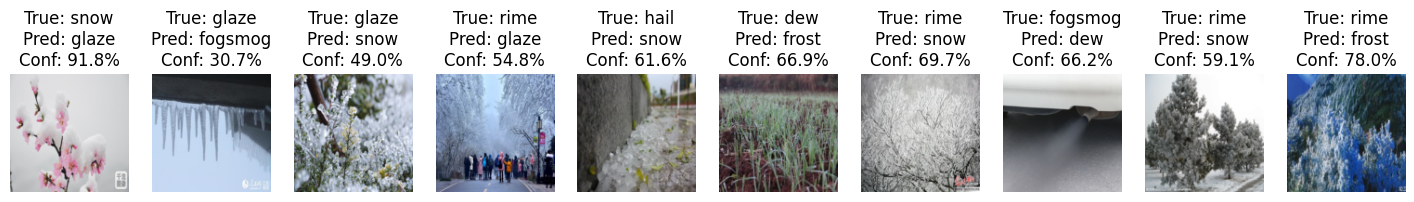

Статистика уверенности:
  Правильные предсказания: 94.92% ± 11.02%
  Неправильные предсказания: 73.19% ± 19.43%
  Общая уверенность: 92.73%


In [74]:
resnet_history = resnet_pipeline.train(criterion, optimizer)

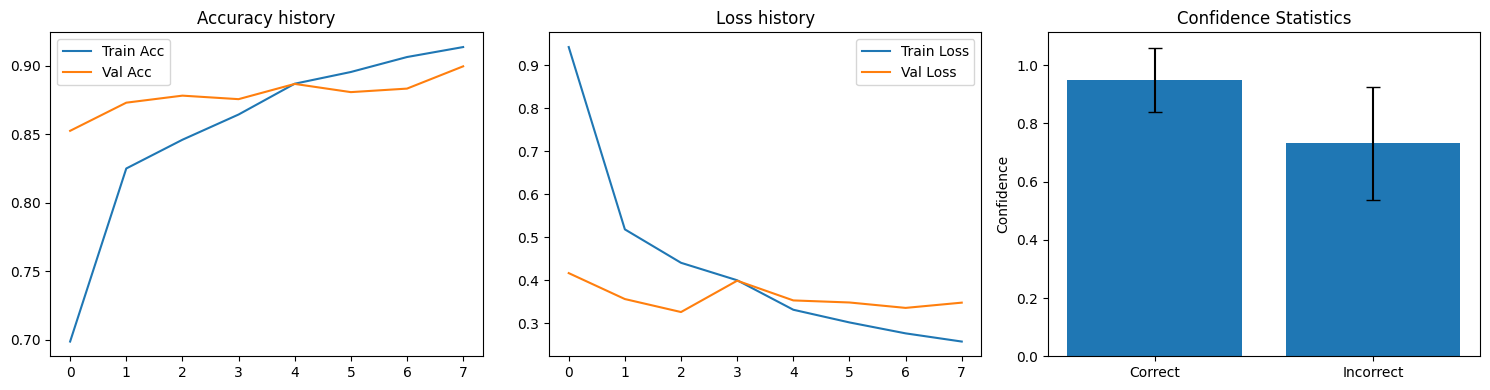

In [75]:
resnet_pipeline.plot_history()

### Efficientnet

In [55]:
model_efficientnet = get_efficientnet_b2(num_classes=num_classes)
model_efficientnet.to(DEVICE)

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [56]:
efficientnet_pipeline = Pipeline(
    model=model_efficientnet,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    class_names=class_names,
    device=DEVICE,
    epochs=20,
    patience=5,
    model_name="efficientnet_b2_weather"
)

In [57]:
optimizer = torch.optim.AdamW(model_efficientnet.parameters(), lr=1e-4, weight_decay=1e-5)
criterion = torch.nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

Результаты на 5 эпохе:
   Train Loss: 0.5686 | Train Acc: 81.7792%
   Val Loss:   0.5503 | Val Acc:   83.2048% | Conf: 87.79%
Результаты на 10 эпохе:
   Train Loss: 0.4235 | Train Acc: 84.7803%
   Val Loss:   0.4845 | Val Acc:   83.5476% | Conf: 88.25%
Результаты на 15 эпохе:
   Train Loss: 0.3033 | Train Acc: 89.1104%
   Val Loss:   0.4441 | Val Acc:   86.9751% | Conf: 91.47%
Результаты на 20 эпохе:
   Train Loss: 0.2043 | Train Acc: 92.8617%
   Val Loss:   0.3896 | Val Acc:   87.2322% | Conf: 92.63%
Точность на тестовой выборке: 87.7670%
Средняя уверенность на тестовой выборке: 92.99%


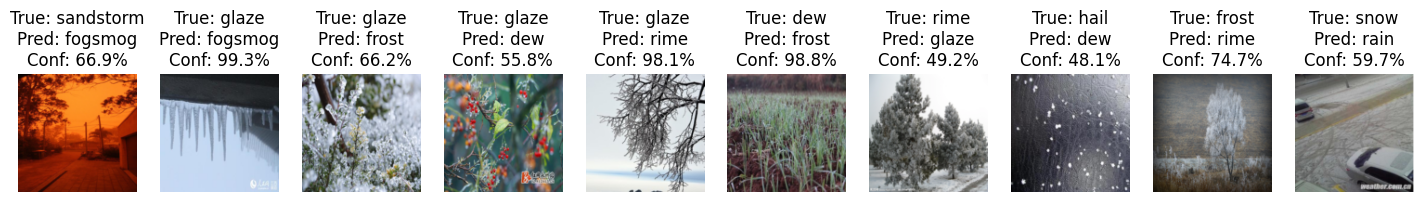

Статистика уверенности:
  Правильные предсказания: 95.43% ± 10.82%
  Неправильные предсказания: 75.48% ± 18.89%
  Общая уверенность: 92.99%


In [58]:
efficientnet_history = efficientnet_pipeline.train(criterion, optimizer, scheduler)

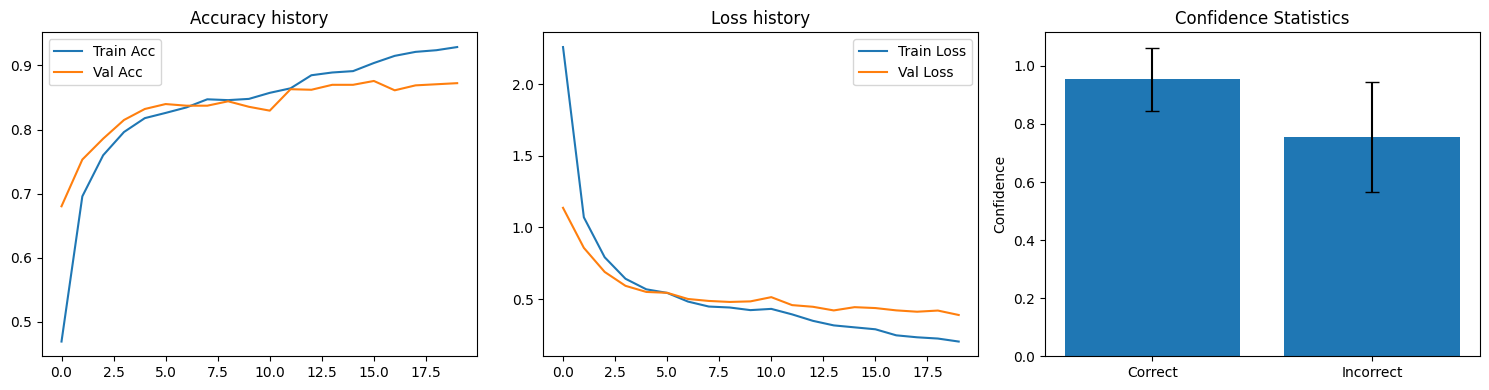

In [59]:
efficientnet_pipeline.plot_history()

In [60]:
print(f"Точность на тестовой выборке (EfficientNet): {efficientnet_pipeline.history['test_acc']:.4f}")

Точность на тестовой выборке (EfficientNet): 0.8777


## Сравнение моделей

In [62]:
model_histories = {
    'MLP': mlp_history,
    'CNN': cnn_history,
    'MobileNet': mobilenet_history,
    'ViT': vit_history,
    'ResNet50': resnet_history,
    'Efficientnet': efficientnet_history,
}

In [65]:
df_comp, df_disp = compare_models(model_histories)
df_disp

Сравнение моделей:


,Model,Best Val Acc,Final Val Acc,Final Train Acc,Test Acc,Best Val Loss,Epochs Trained,Avg Confidence
3,ViT,93.74%,93.74%,99.96%,93.20%,0.1965,8,96.33%
4,ResNet50,91.35%,90.92%,96.59%,89.51%,0.3252,20,95.28%
5,Efficientnet,87.57%,87.23%,92.86%,87.77%,0.3896,20,92.99%
2,MobileNet,85.09%,85.09%,84.12%,82.72%,0.4304,15,86.98%
1,CNN,73.61%,72.41%,65.19%,72.52%,0.8041,17,69.79%
0,MLP,54.93%,54.50%,47.12%,54.66%,1.3909,30,50.56%


In [91]:
top3_models = {
    'ViT': {
        "model": wrapped_vit,
        "loader": vit_test_loader
    },
    'ResNet50': {
        "model": resnet_model,
        "loader": test_loader
    },
    'EfficientNet': {
        "model": model_efficientnet,
        "loader": test_loader
    }
}


ViT Classification Report:
              precision    recall  f1-score   support

         dew       0.97      0.95      0.96       105
     fogsmog       0.93      0.98      0.95       128
       frost       0.87      0.83      0.85        71
       glaze       0.88      0.92      0.90        96
        hail       0.96      0.99      0.97        89
   lightning       1.00      1.00      1.00        56
        rain       0.94      0.95      0.94        79
     rainbow       1.00      1.00      1.00        35
        rime       0.89      0.93      0.91       174
   sandstorm       0.98      0.91      0.95       104
        snow       0.93      0.84      0.88        93

    accuracy                           0.93      1030
   macro avg       0.94      0.94      0.94      1030
weighted avg       0.93      0.93      0.93      1030


ResNet50 Classification Report:
              precision    recall  f1-score   support

         dew       0.89      0.96      0.92       105
     fogsmog     

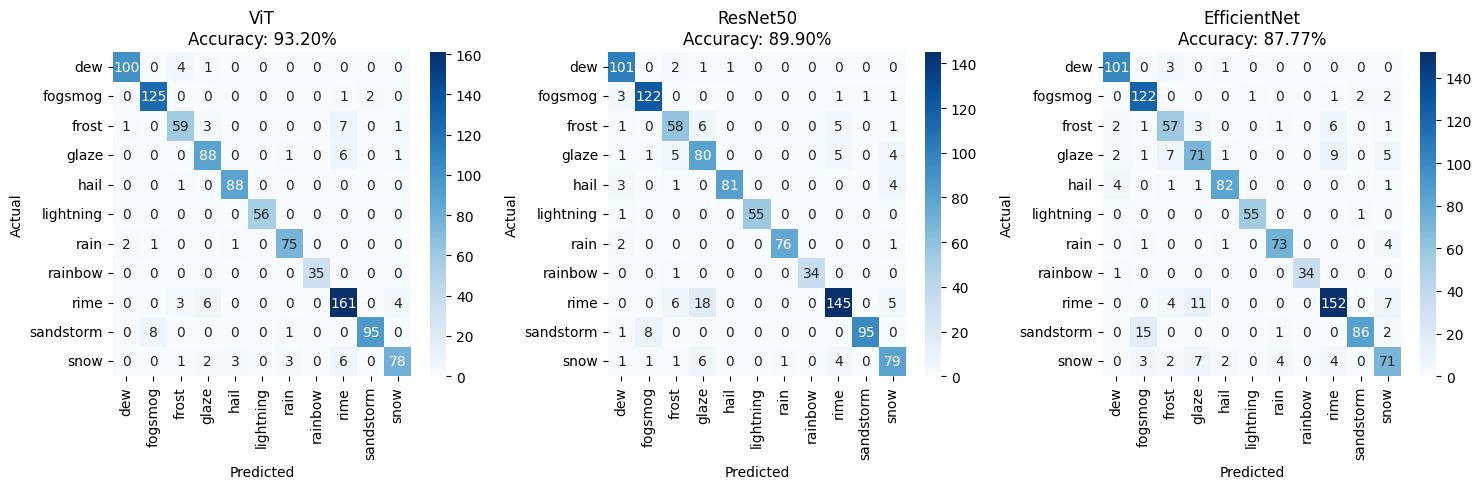

In [92]:
cm = plot_confusion_matrices(top3_models, class_names, DEVICE)